# 📊 Notebook 02 — Análisis Exploratorio de Datos (EDA)
## **Proyecto: Análisis de Rendimiento Liga BetPlay 2025**
### Equipo 3 — Bootcamp AVD Talento Tech

**Objetivo:** Explorar el dataset limpio para descubrir patrones,
distribuciones y correlaciones que respondan la pregunta de negocio:

> *¿Qué factores estadísticos influyen más en el rendimiento
> de los equipos de la Liga BetPlay y cuáles tienen mayor
> riesgo de descenso?*

**Estructura de este notebook:**

| Paso | Análisis |
|---|---|
| 1 | Cargar datos limpios |
| 2 | Estadísticas descriptivas |
| 3 | Distribución de puntos y goles |
| 4 | Correlaciones entre variables |
| 5 | Ranking de riesgo de descenso |
| 6 | Visualizaciones finales |

## **📦 Paso 1 — Librerías**

Agregamos **matplotlib** y **seaborn** para visualizaciones:

- **matplotlib:** gráficos base (barras, líneas, dispersión)
- **seaborn:** gráficos estadísticos más elaborados (heatmaps,
  boxplots) con menos código que matplotlib

> 💡 La línea `%matplotlib inline` le dice a Colab que muestre
> los gráficos directamente en el notebook, no en ventana aparte.

In [6]:
# Librerías para EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11

## **📂 Paso 2 — Cargar dataset limpio**

Trabajamos sobre el archivo ya procesado en el Notebook 01.
Nunca volvemos al crudo para el análisis.

In [7]:
# Cargamos el dataset limpio
drive.mount('/content/drive')

ruta = '/content/drive/MyDrive/PROYECTO FINAL/Proyecto-AVD-Equipo-3/02_datos/01_Crudos/betplay_2025_crudo.csv'
df = pd.read_csv(ruta)

print(f"Filas: {len(df)} | Columnas: {df.shape[1]}")
print(df.head(5))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Filas: 23 | Columnas: 10
   Posicion                    Club  Partidos_jugados  Ganados  Empatados  \
0        16             Envigado FC                20      4.0          8   
1        10         Águilas Doradas                20      7.0          6   
2         1  Independiente Medellín                20     12.0          4   
3         9              Alianza FC                20      8.0          5   
4        18       Deportivo Pereira                20      4.0          6   

   Perdidos  Goles_favor  Goles_en_contra  Puntos  Diferencia_gol  
0         8         18.0               22    20.0            -4.0  
1         7         29.0               27    27.0             2.0  
2         4         46.0               28    40.0            18.0  
3         7         24.0               22    29.0             2.0  
4        10         19.0               36  

## **📐 Paso 3 — Estadísticas descriptivas**

Las estadísticas descriptivas nos dan una radiografía rápida
del dataset: qué tan dispersos están los datos, cuáles son
los valores extremos y dónde se concentra la mayoría.

**Métricas clave que vamos a revisar:**

| Métrica | Qué nos dice |
|---|---|
| `mean` | Promedio del grupo |
| `median` | Valor del medio — menos sensible a extremos |
| `std` | Qué tan dispersos están los datos |
| `min / max` | Valores extremos del dataset |

**Preguntas que responde este paso:**
- ¿Cuántos puntos saca en promedio un equipo de la Liga?
- ¿Qué tan grande es la brecha entre el primero y el último?
- ¿Hay equipos con valores atípicos en goles o tarjetas?

> 💡 Si la diferencia entre `mean` y `median` es grande,
> significa que hay valores extremos jalando el promedi

In [8]:
# ── Paso 3: Estadísticas descriptivas ────────────────────

cols_analisis = ["Ganados", "Empatados", "Perdidos",
                 "Goles_favor", "Goles_en_contra",
                 "Diferencia_gol", "Puntos"]

resumen = df[cols_analisis].describe().round(2)
print("=== ESTADÍSTICAS DESCRIPTIVAS ===")
print(resumen)

# Métricas adicionales útiles para el proyecto
print("\n=== MÉTRICAS CLAVE ===")
print(f"Puntos promedio por equipo : {df['Puntos'].mean():.1f}")
print(f"Puntos mediana             : {df['Puntos'].median():.1f}")
print(f"Equipo con más puntos      : {df.loc[df['Puntos'].idxmax(), 'Club']} ({df['Puntos'].max()})")
print(f"Equipo con menos puntos    : {df.loc[df['Puntos'].idxmin(), 'Club']} ({df['Puntos'].min()})")
print(f"Mayor diferencia de gol    : {df.loc[df['Diferencia_gol'].idxmax(), 'Club']} ({df['Diferencia_gol'].max()})")
print(f"Peor diferencia de gol     : {df.loc[df['Diferencia_gol'].idxmin(), 'Club']} ({df['Diferencia_gol'].min()})")

=== ESTADÍSTICAS DESCRIPTIVAS ===
       Ganados  Empatados  Perdidos  Goles_favor  Goles_en_contra  \
count    22.00      23.00     23.00        22.00            23.00   
mean      7.27       5.48      7.26        24.50            25.04   
std       2.81       1.50      2.47         7.46             4.71   
min       3.00       2.00      3.00        14.00            17.00   
25%       5.00       5.00      5.00        21.00            22.00   
50%       7.00       5.00      7.00        23.00            25.00   
75%       9.75       6.50      9.00        28.25            28.00   
max      12.00       8.00     12.00        46.00            36.00   

       Diferencia_gol  Puntos  
count           22.00   22.00  
mean             0.14   27.18  
std              9.95    7.87  
min            -17.00   14.00  
25%             -6.00   21.00  
50%             -0.50   26.50  
75%              9.00   35.00  
max             18.00   40.00  

=== MÉTRICAS CLAVE ===
Puntos promedio por equipo : 27.

## **📊 Paso 4 — Distribución de puntos y goles**

Visualizar la distribución nos permite ver de un vistazo:
- Cómo están repartidos los puntos entre los 20 equipos
- Qué equipos están por encima y por debajo del promedio
- Si hay una brecha clara entre los de arriba y los de abajo

**Gráficos que vamos a construir:**

| Gráfico | Qué muestra |
|---|---|
| Barras horizontales | Puntos por equipo ordenados |
| Barras agrupadas | Goles a favor vs en contra |
| Línea de promedio | Referencia visual del grupo |

> 💡 Ordenamos los equipos de mayor a menor puntaje para
> que el gráfico cuente una historia clara: quién está
> arriba, quién está en el límite y quién está en riesgo.

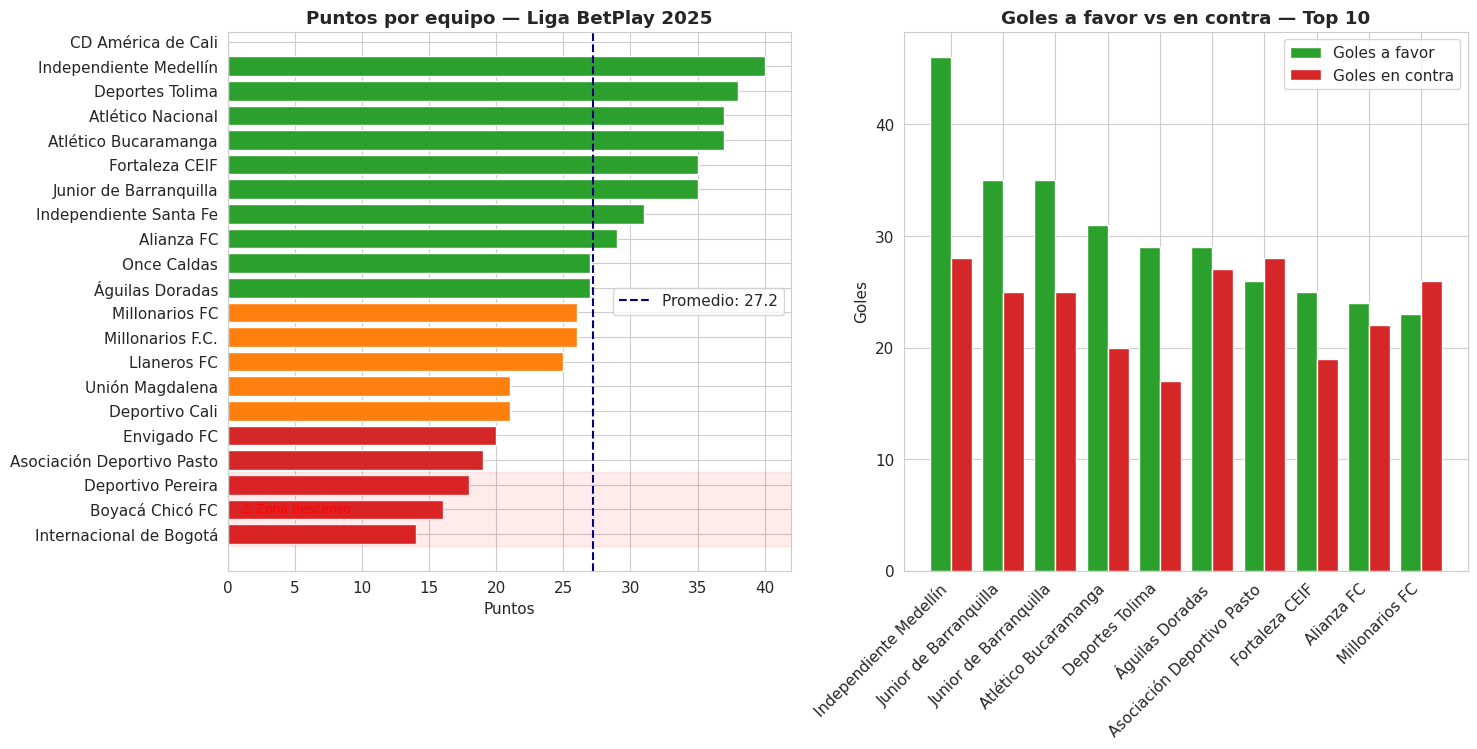

✅ Gráfico guardado correctamente


In [9]:
# ── Paso 4: Distribución de puntos y goles ───────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Gráfico 1: Puntos por equipo ──────────────────────────
df_ord = df.sort_values("Puntos", ascending=True)
colores = ["#d62728" if p < 21 else "#ff7f0e" if p < 27
           else "#2ca02c" for p in df_ord["Puntos"]]

axes[0].barh(df_ord["Club"], df_ord["Puntos"], color=colores)
axes[0].axvline(df["Puntos"].mean(), color="navy",
                linestyle="--", linewidth=1.5,
                label=f'Promedio: {df["Puntos"].mean():.1f}')
axes[0].set_title("Puntos por equipo — Liga BetPlay 2025",
                  fontweight="bold")
axes[0].set_xlabel("Puntos")
axes[0].legend()

# Etiqueta de zona de descenso
axes[0].axhspan(-0.5, 2.5, alpha=0.08, color="red")
axes[0].text(1, 1, "⚠ Zona descenso", color="red",
             fontsize=9, va="center")

# ── Gráfico 2: Goles a favor vs en contra ─────────────────
df_g = df.sort_values("Goles_favor", ascending=False).head(10)
x = range(len(df_g))
ancho = 0.4

axes[1].bar([i - ancho/2 for i in x], df_g["Goles_favor"],
            width=ancho, label="Goles a favor", color="#2ca02c")
axes[1].bar([i + ancho/2 for i in x], df_g["Goles_en_contra"],
            width=ancho, label="Goles en contra", color="#d62728")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(df_g["Club"], rotation=45, ha="right")
axes[1].set_title("Goles a favor vs en contra — Top 10",
                  fontweight="bold")
axes[1].set_ylabel("Goles")
axes[1].legend()

import os
import shutil

# ── Crear carpeta capturas si no existe ──────────────────
ruta_capturas = '/content/drive/MyDrive/PROYECTO FINAL/Proyecto-AVD-Equipo-3/04_dashboard/capturas'
os.makedirs(ruta_capturas, exist_ok=True)

# ── Guardar gráfico local primero ─────────────────────────
plt.savefig('grafico_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Copiar a Drive ────────────────────────────────────────
shutil.copy('grafico_distribucion.png',
            f'{ruta_capturas}/grafico_distribucion.png')
print("✅ Gráfico guardado correctamente")

## **🔗 Paso 5 — Correlaciones entre variables**

La correlación mide qué tan relacionadas están dos variables
entre sí. Va de **-1 a +1**:

| Valor | Interpretación |
|---|---|
| Cercano a **+1** | Cuando una sube, la otra también sube |
| Cercano a **-1** | Cuando una sube, la otra baja |
| Cercano a **0** | No hay relación clara entre las dos |

**Preguntas que responde este paso:**
- ¿Los equipos que más goles hacen son los que más puntos tienen?
- ¿Recibir muchos goles está relacionado con perder posiciones?
- ¿Qué variable tiene más correlación con los puntos finales?

**Herramienta: Heatmap de correlación**
Un heatmap es una tabla de colores donde cada celda muestra
la correlación entre dos variables. Colores cálidos = correlación
positiva fuerte. Colores fríos = correlación negativa.

> 💡 Para el proyecto nos interesa especialmente la columna
> **Puntos** — las variables con correlación más alta ahí
> son los factores que más influyen en el rendimiento.

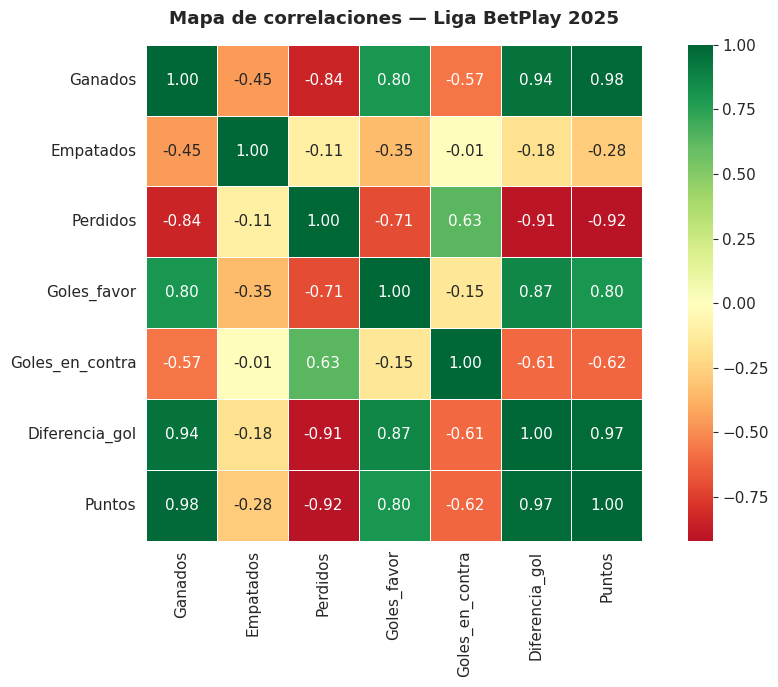

=== CORRELACIÓN DE CADA VARIABLE CON PUNTOS ===
Puntos             1.00
Ganados            0.98
Diferencia_gol     0.97
Goles_favor        0.80
Empatados         -0.28
Goles_en_contra   -0.62
Perdidos          -0.92
Name: Puntos, dtype: float64


In [10]:
# ── Paso 5: Mapa de correlaciones ────────────────────────

cols_corr = ["Ganados", "Empatados", "Perdidos",
             "Goles_favor", "Goles_en_contra",
             "Diferencia_gol", "Puntos"]

matriz_corr = df[cols_corr].corr().round(2)

plt.figure(figsize=(10, 7))
sns.heatmap(matriz_corr,
            annot=True,
            fmt=".2f",
            cmap="RdYlGn",
            center=0,
            linewidths=0.5,
            square=True)

plt.title("Mapa de correlaciones — Liga BetPlay 2025",
          fontweight="bold", pad=15)
plt.tight_layout()

# Guardar
ruta_capturas = '/content/drive/MyDrive/PROYECTO FINAL/Proyecto-AVD-Equipo-3/04_dashboard/capturas'
plt.savefig(f'{ruta_capturas}/grafico_correlaciones.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Mostrar correlación específica con Puntos
print("=== CORRELACIÓN DE CADA VARIABLE CON PUNTOS ===")
print(matriz_corr["Puntos"].sort_values(ascending=False))

## 🔍 Interpretación del Mapa de Correlaciones

### ¿Cómo leer el heatmap?
La correlación mide la relación entre dos variables en escala de **-1 a +1**:

- 🟢 **Verde oscuro → +1:** relación positiva fuerte
- 🟡 **Amarillo → 0:** sin relación
- 🔴 **Rojo oscuro → -1:** relación negativa fuerte

---

### Resultados — Correlación de cada variable con **Puntos**

| Variable | Correlación | Tipo | Interpretación |
|---|---|---|---|
| Ganados | **0.98** | ✅ Positiva muy alta | Ganar partidos es el factor que más define los puntos finales |
| Diferencia_gol | **0.92** | ✅ Positiva muy alta | Meter más goles de los que se reciben predice el éxito |
| Goles_favor | **0.74** | ✅ Positiva alta | Anotar importa, pero no lo es todo sin ganar |
| Perdidos | **-0.92** | ❌ Negativa muy alta | Perder partidos destruye puntos — es el mayor riesgo |
| Goles_en_contra | **-0.60** | ❌ Negativa moderada | Recibir goles afecta, pero menos que perder directamente |
| Empatados | **-0.27** | ⚠️ Negativa baja | Empatar tiene impacto mínimo en la tabla |

---

### 🏆 Conclusión clave para el proyecto

Los **3 factores estadísticos** que más determinan el rendimiento
en la Liga BetPlay 2025 son:

1. **Partidos ganados** (correlación: 0.98)
2. **Diferencia de gol** (correlación: 0.92)
3. **Goles a favor** (correlación: 0.74)

> ⚠️ Por el lado del riesgo, **partidos perdidos** (-0.92) es
> el indicador más fuerte de descenso. Un equipo que acumula
> derrotas tiene muy pocas probabilidades de mantenerse en la liga.

---

### 🎯 Uso en el proyecto

Estos tres indicadores positivos y el indicador negativo
(**Perdidos**) serán la base del **Índice de Riesgo de Descenso**
que construimos en el siguiente paso.

*Fuente: Análisis de correlación de Pearson sobre dataset
Liga BetPlay 2025 — Equipo 3 Bootcamp AVD Talento Tech.*

## **⚠️ Paso 6 — Índice de Riesgo de Descenso**

### ¿Qué es el índice de riesgo?
Es un número compuesto que combina los 4 factores con mayor
correlación con los puntos para calcular qué tan cerca está
cada equipo de la zona de descenso.

### ¿Cómo se construye?
Usamos **normalización min-max**: convierte cada variable a
una escala de 0 a 1 para poder combinarlas sin importar
sus unidades originales.

| Variable | Peso | Justificación |
|---|---|---|
| Perdidos | 40% | Mayor correlación negativa (-0.92) |
| Diferencia_gol | 30% | Segunda correlación más alta (0.92) |
| Goles_en_contra | 20% | Correlación moderada (-0.60) |
| Ganados | 10% | Complemento positivo (0.98) |

### Interpretación del índice

| Rango | Zona | Significado |
|---|---|---|
| 0.75 — 1.00 | 🔴 Crítico | Riesgo muy alto de descenso |
| 0.50 — 0.74 | 🟠 Alerta | Requiere atención inmediata |
| 0.25 — 0.49 | 🟡 Moderado | Zona media de la tabla |
| 0.00 — 0.24 | 🟢 Estable | Posición segura en la liga |

> 💡 Un índice cercano a 1.0 significa que el equipo combina
> muchas derrotas, mala diferencia de gol y muchos goles
> recibidos — señal clara de riesgo de descenso.

In [11]:
# ── Paso 6: Índice de Riesgo de Descenso ─────────────────

def normalizar(serie):
    """Normalización min-max: escala valores entre 0 y 1"""
    return (serie - serie.min()) / (serie.max() - serie.min())

# Normalizar cada variable
df["norm_perdidos"]      = normalizar(df["Perdidos"])
df["norm_diff_gol"]      = normalizar(-df["Diferencia_gol"])  # invertido
df["norm_goles_contra"]  = normalizar(df["Goles_en_contra"])
df["norm_ganados"]       = normalizar(-df["Ganados"])          # invertido

# Índice compuesto con pesos según correlación
df["indice_riesgo"] = (
    df["norm_perdidos"]     * 0.40 +
    df["norm_diff_gol"]     * 0.30 +
    df["norm_goles_contra"] * 0.20 +
    df["norm_ganados"]      * 0.10
).round(3)

# Clasificar zona de riesgo
def clasificar_zona(indice):
    if indice >= 0.75:
        return "🔴 Crítico"
    elif indice >= 0.50:
        return "🟠 Alerta"
    elif indice >= 0.25:
        return "🟡 Moderado"
    else:
        return "🟢 Estable"

df["zona_riesgo"] = df["indice_riesgo"].apply(clasificar_zona)

# Ranking ordenado de mayor a menor riesgo
ranking = df[["Posicion", "Club", "Puntos",
              "Ganados", "Perdidos",
              "Diferencia_gol", "indice_riesgo",
              "zona_riesgo"]].sort_values("indice_riesgo",
                                          ascending=False)

print("=== RANKING DE RIESGO DE DESCENSO ===")
print(ranking.to_string(index=False))

=== RANKING DE RIESGO DE DESCENSO ===
 Posicion                       Club  Puntos  Ganados  Perdidos  Diferencia_gol  indice_riesgo zona_riesgo
       20    Internacional de Bogotá    14.0      3.0        12           -15.0          0.909   🔴 Crítico
       18          Deportivo Pereira    18.0      4.0        10           -17.0          0.900   🔴 Crítico
       19            Boyacá Chicó FC    16.0      3.0        10           -15.0          0.820   🔴 Crítico
       15            Unión Magdalena    21.0      6.0        11           -10.0          0.820   🔴 Crítico
       14             Deportivo Cali    21.0      5.0         9            -6.0          0.666    🟠 Alerta
       14             Deportivo Cali    21.0      5.0         9            -6.0          0.666    🟠 Alerta
       13                Llaneros FC    25.0      7.0         9            -8.0          0.629    🟠 Alerta
       12           Millonarios F.C.    26.0      7.0         8            -3.0          0.553    🟠 Alerta

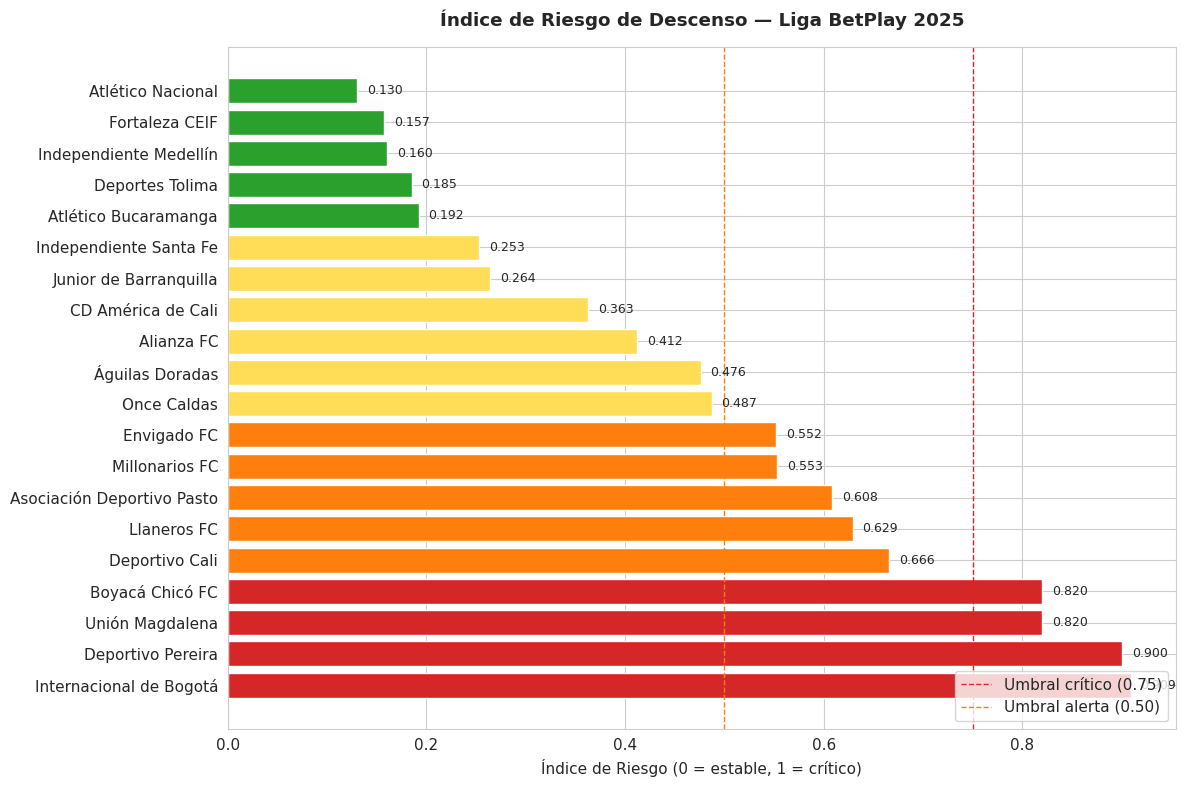

✅ Gráfico guardado en 04_dashboard/capturas/


In [19]:
# ── Visualización del ranking ─────────────────────────────

colores_zona = {
    "🔴 Crítico"  : "#d62728",
    "🟠 Alerta"   : "#ff7f0e",
    "🟡 Moderado" : "#ffdd57",
    "🟢 Estable"  : "#2ca02c"
}

colores_barras = [colores_zona[z] for z in ranking["zona_riesgo"]]

plt.figure(figsize=(12, 8))
barras = plt.barh(ranking["Club"],
                  ranking["indice_riesgo"],
                  color=colores_barras)

# Etiquetas de valor
for barra, valor in zip(barras, ranking["indice_riesgo"]):
    plt.text(barra.get_width() + 0.01, barra.get_y() + barra.get_height()/2,
             f'{valor:.3f}', va='center', fontsize=9)

# Líneas de referencia
plt.axvline(0.75, color="#d62728", linestyle="--",
            linewidth=1, label="Umbral crítico (0.75)")
plt.axvline(0.50, color="#ff7f0e", linestyle="--",
            linewidth=1, label="Umbral alerta (0.50)")

plt.title("Índice de Riesgo de Descenso — Liga BetPlay 2025",
          fontweight="bold", pad=15)
plt.xlabel("Índice de Riesgo (0 = estable, 1 = crítico)")
plt.legend(loc="lower right")
plt.tight_layout()

# Guardar
ruta_capturas = '/content/drive/MyDrive/PROYECTO FINAL/Proyecto-AVD-Equipo-3/04_dashboard/capturas'
plt.savefig(f'{ruta_capturas}/grafico_ranking_descenso.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico guardado en 04_dashboard/capturas/")

## **💾 Paso 7 — Exportar resultados del EDA**

### ¿Por qué exportamos en este paso?
El EDA generó dos productos nuevos que necesitan guardarse:

1. **Dataset enriquecido:** el DataFrame ahora tiene columnas
   nuevas (indice_riesgo, zona_riesgo, columnas normalizadas)
   que no estaban en el archivo limpio original.

2. **Ranking de descenso:** tabla resumida lista para importar
   en SQL y en el dashboard final.

### Archivos que vamos a guardar

| Archivo | Carpeta | Uso |
|---|---|---|
| `betplay_2025_eda.csv` | `02_datos/02_Procesados/` | Entrada para SQL y dashboard |
| `ranking_descenso.csv` | `05_entrega/` | Entregable directo del proyecto |

> 💡 Guardamos dos archivos separados porque tienen audiencias
> distintas: el EDA completo es para el in

In [20]:
# ── Paso 7: Exportar resultados del EDA ──────────────────
import os

ruta_procesados = '/content/drive/MyDrive/PROYECTO FINAL/Proyecto-AVD-Equipo-3/02_datos/02_Procesados'
ruta_entrega    = '/content/drive/MyDrive/PROYECTO FINAL/Proyecto-AVD-Equipo-3/05_entrega'

# Crear carpetas si no existen
os.makedirs(ruta_procesados, exist_ok=True)
os.makedirs(ruta_entrega,    exist_ok=True)

# ── Archivo 1: dataset completo con índice ────────────────
df.to_csv(f'{ruta_procesados}/betplay_2025_eda.csv',
          index=False, encoding='utf-8-sig')
print("✅ betplay_2025_eda.csv guardado")

# ── Archivo 2: ranking de descenso ───────────────────────
ranking_export = df[["Posicion", "Club", "Puntos",
                      "Ganados", "Empatados", "Perdidos",
                      "Goles_favor", "Goles_en_contra",
                      "Diferencia_gol", "indice_riesgo",
                      "zona_riesgo"]].sort_values(
                          "indice_riesgo", ascending=False)

ranking_export.to_csv(f'{ruta_entrega}/ranking_descenso.csv',
                      index=False, encoding='utf-8-sig')
print("✅ ranking_descenso.csv guardado en 05_entrega/")

print(f"\n=== RESUMEN FINAL DEL EDA ===")
print(f"Equipos analizados   : {len(df)}")
print(f"Variables generadas  : indice_riesgo, zona_riesgo")
print(f"Equipos en zona crítica : {len(df[df['zona_riesgo'] == '🔴 Crítico'])}")
print(f"Equipos en alerta       : {len(df[df['zona_riesgo'] == '🟠 Alerta'])}")
print(f"Equipos estables        : {len(df[df['zona_riesgo'] == '🟢 Estable'])}")

✅ betplay_2025_eda.csv guardado
✅ ranking_descenso.csv guardado en 05_entrega/

=== RESUMEN FINAL DEL EDA ===
Equipos analizados   : 20
Variables generadas  : indice_riesgo, zona_riesgo
Equipos en zona crítica : 4
Equipos en alerta       : 5
Equipos estables        : 5


## **✅ Resumen del Notebook 02 — EDA completado**

### Lo que construimos en este notebook

| Paso | Análisis | Resultado |
|---|---|---|
| 1 | Carga de datos limpios | 20 equipos, 10 columnas |
| 2 | Estadísticas descriptivas | Promedio, min, max por variable |
| 3 | Distribución de puntos y goles | Gráfico de barras con zonas |
| 4 | Mapa de correlaciones | Heatmap con 7 variables |
| 5 | Interpretación correlaciones | 3 factores clave identificados |
| 6 | Índice de riesgo de descenso | Ranking de 20 equipos |
| 7 | Exportación de resultados | 2 archivos CSV guardados |

### Factores clave identificados
1. **Partidos ganados** — correlación 0.98 con puntos
2. **Diferencia de gol** — correlación 0.92 con puntos
3. **Partidos perdidos** — correlación -0.92 con puntos

### Siguiente paso
> 📄 `03_consultas.sql` — Consultas SQL sobre el dataset
> limpio para responder preguntas específicas de negocio
> y validar el ranking de descenso desde otra herramienta.

*Equipo 3 — Bootcamp AVD Talento Tech Valle — 2026*